In [1]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', '--index-url', 
                'https://download.pytorch.org/whl/cu118', '-q'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 71.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 39.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 91.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 117.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.2/905.2 MB 811.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.7.1+cu118 which is incompatible.


CompletedProcess(args=['pip', 'install', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu118', '-q'], returncode=0)

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(99)
np.random.seed(99)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [4]:
def soliton(x, t, c, x0):
    arg = (torch.sqrt(torch.tensor(float(c))) / 2.0) * (x - c * t - x0)
    return (c / 2.0) / torch.cosh(arg) ** 2

In [5]:
def make_config(N, d=10.0, T=5.0):
    speeds = [1.5 + 0.5 * (N - 1 - k) for k in range(N)]
    x0s    = [((N - 1) / 2.0 - k) * d  for k in range(N)]
    c_max   = speeds[0]
    x_left  = x0s[-1] - 10.0
    x_right = x0s[0]  + c_max * T + 15.0
    return speeds, x0s, (x_left, x_right)

In [6]:
def n_soliton(x, t, speeds, x0s):
    u = torch.zeros_like(x, dtype=torch.float32)
    for c, x0 in zip(speeds, x0s):
        u = u + soliton(x, t, float(c), float(x0))
    return u

In [7]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [2, 50, 50, 50, 50, 50, 50, 1]
        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        for layer in self.layers:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            z = torch.tanh(layer(z))
        return self.layers[-1](z)

m = PINN()
print(f'params: {sum(p.numel() for p in m.parameters()):,}')  # should be ~15k

params: 12,951


In [8]:
def derivatives(model, x, t):
    u     = model(x, t)
    u_x   = torch.autograd.grad(u,    x,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_t   = torch.autograd.grad(u,    t,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx  = torch.autograd.grad(u_x,  x,  grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x,  grad_outputs=torch.ones_like(u_xx),create_graph=True)[0]
    return u, u_t, u_x, u_xxx

def pde_loss(model, x, t):
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    res = u_t + 6.0 * u * u_x + u_xxx
    return torch.mean(res ** 2)

def ic_loss(model, x_ic, t_ic, exact_fn):
    u_pred  = model(x_ic, t_ic)
    u_exact = exact_fn(x_ic.squeeze(), t_ic.squeeze()).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)

def bc_loss(model, x_bc, t_bc):
    return torch.mean(model(x_bc, t_bc) ** 2)

def data_loss(model, x_d, t_d, u_d):
    return torch.mean((model(x_d, t_d) - u_d) ** 2)

def total_loss(model, batch, exact_fn):
    x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d = batch
    lp = pde_loss (model, x_pde, t_pde)
    li = ic_loss  (model, x_ic,  t_ic, exact_fn)
    lb = bc_loss  (model, x_bc,  t_bc)
    ld = data_loss(model, x_d,   t_d,  u_d)
    return lp + li + lb + ld, lp, li, lb, ld

In [9]:
def build_data(speeds, x0s, domain, T, n_pde, device):
    xl, xr = domain
    width  = xr - xl
    scale  = width / 60.0   # same scale factor as baseline

    # data/IC/BC stay fixed — only PDE collocation count changes
    n_data = int(400  * scale)
    n_ic   = max(500, int(500 * scale))
    n_bc   = 100

    x_pde = (xl + width * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
    t_pde = (T  *         torch.rand(n_pde, 1)).to(device).requires_grad_(True)

    x_d = (xl + width * torch.rand(n_data, 1)).to(device)
    t_d = (T  *         torch.rand(n_data, 1)).to(device)
    efn = lambda x, t: n_soliton(x, t, speeds, x0s)
    u_d = efn(x_d.squeeze(), t_d.squeeze()).unsqueeze(1).to(device)

    x_ic = torch.linspace(xl, xr, n_ic).view(-1, 1).to(device).requires_grad_(True)
    t_ic = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

    t_bc_v     = torch.linspace(0, T, n_bc).view(-1, 1).to(device)
    x_bc_left  = torch.full((n_bc, 1), float(xl)).to(device).requires_grad_(True)
    x_bc_right = torch.full((n_bc, 1), float(xr)).to(device).requires_grad_(True)
    x_bc = torch.cat([x_bc_left,  x_bc_right], dim=0)
    t_bc = torch.cat([t_bc_v, t_bc_v], dim=0).requires_grad_(True)

    print(f'  PDE: {n_pde:,}  |  Data: {n_data:,}  |  IC: {n_ic:,}  |  BC: {2*n_bc}')
    return (x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d), efn

In [10]:
def compute_l2(model, exact_fn, domain, T, nx=500, nt=100):
    xl, xr = domain
    x_g = torch.linspace(xl, xr, nx)
    t_g = torch.linspace(0,   T,  nt)
    X, TT = torch.meshgrid(x_g, t_g, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)
    with torch.no_grad():
        u_pred = model(xf, tf).cpu().numpy().reshape(nx, nt)
    u_exact = exact_fn(X.reshape(-1), TT.reshape(-1)).numpy().reshape(nx, nt)
    return float(np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2)))

In [11]:
def train_model(N, speeds, x0s, domain, n_pde, T=5.0, n_adam=15000, n_lbfgs=2000):
    print(f'\n{"="*65}')
    print(f'  N={N}  |  n_pde={n_pde:,}  |  6x50 architecture')
    print(f'  domain=[{domain[0]:.1f}, {domain[1]:.1f}]')
    print(f'{"="*65}')

    batch, exact_fn = build_data(speeds, x0s, domain, T, n_pde, device)
    model = PINN().to(device)

    t0 = time.time()

    # Adam
    opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {k: [] for k in ('total', 'pde', 'ic', 'bc', 'data')}

    for i in range(n_adam):
        opt_adam.zero_grad()
        loss, lp, li, lb, ld = total_loss(model, batch, exact_fn)
        loss.backward()
        opt_adam.step()
        hist['total'].append(loss.item())
        hist['pde'].append(lp.item())
        hist['ic'].append(li.item())
        hist['bc'].append(lb.item())
        hist['data'].append(ld.item())
        if i % 1000 == 0:
            print(f'  Adam {i:5d} | Total={loss.item():.6f}  PDE={lp.item():.6f}  IC={li.item():.6f}  Data={ld.item():.6f}')

    t_adam = time.time() - t0
    l2_adam = compute_l2(model, exact_fn, domain, T)
    final_adam_loss = hist['total'][-1]
    print(f'  >> Adam done {t_adam:.1f}s  |  L2={l2_adam*100:.4f}%  |  loss={final_adam_loss:.6f}')

    # L-BFGS
    t1 = time.time()
    opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

    for i in range(n_lbfgs):
        def closure():
            opt_lbfgs.zero_grad()
            loss, *_ = total_loss(model, batch, exact_fn)
            loss.backward()
            return loss
        opt_lbfgs.step(closure)
        if i % 200 == 0:
            loss, *_ = total_loss(model, batch, exact_fn)
            print(f'  LBFGS {i:4d} | Total={loss.item():.8f}')

    t_lbfgs = time.time() - t1
    l2_final = compute_l2(model, exact_fn, domain, T)
    loss_final, *_ = total_loss(model, batch, exact_fn)
    print(f'  >> LBFGS done {t_lbfgs:.1f}s  |  L2={l2_final*100:.4f}%  |  loss={loss_final.item():.8f}')

    return model, exact_fn, hist, {
        'N': N,
        'n_pde': n_pde,
        'l2_adam': l2_adam,
        'l2_final': l2_final,
        'final_adam_loss': final_adam_loss,
        'final_lbfgs_loss': loss_final.item(),
        'time_adam': t_adam,
        'time_lbfgs': t_lbfgs,
        'domain': domain,
    }

In [12]:
T_END = 5.0

# (N, n_pde)
# N=9: 5k, 10k, 20k, 40k, 80k
# N=12: 20k, 40k, 80k, 160k
sweep_configs = [
    (9,   5000),
    (9,  10000),
    (9,  20000),
    (9,  40000),
    (9,  80000),
    (12, 20000),
    (12, 40000),
    (12, 80000),
    (12,160000),
]

# precompute domains once — same across all runs of same N
configs_meta = {}
for N in [9, 12]:
    speeds, x0s, domain = make_config(N, T=T_END)
    configs_meta[N] = (speeds, x0s, domain)
    print(f'N={N}: domain={domain}, width={domain[1]-domain[0]:.1f}')

N=9: domain=(-50.0, 82.5), width=132.5
N=12: domain=(-65.0, 105.0), width=170.0


In [13]:
sweep_results = {}

for N, n_pde in sweep_configs:
    speeds, x0s, domain = configs_meta[N]
    model, efn, hist, rec = train_model(N, speeds, x0s, domain, n_pde=n_pde, T=T_END)
    key = f'N{N}_pde{n_pde}'
    sweep_results[key] = dict(model=model, exact_fn=efn, hist=hist, **rec)
    torch.save(model.state_dict(), f'checkpoint_{key}.pt')
    print(f'  saved: checkpoint_{key}.pt\n')


  N=9  |  n_pde=5,000  |  6x50 architecture
  domain=[-50.0, 82.5]
  PDE: 5,000  |  Data: 883  |  IC: 1,104  |  BC: 200


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Adam     0 | Total=0.877435  PDE=0.001193  IC=0.385888  Data=0.413460
  Adam  1000 | Total=0.275179  PDE=0.014794  IC=0.129073  Data=0.131044
  Adam  2000 | Total=0.167765  PDE=0.007936  IC=0.081958  Data=0.077660
  Adam  3000 | Total=0.117339  PDE=0.018353  IC=0.052466  Data=0.046482
  Adam  4000 | Total=0.052603  PDE=0.012980  IC=0.017689  Data=0.021570
  Adam  5000 | Total=0.028844  PDE=0.010158  IC=0.007913  Data=0.010655
  Adam  6000 | Total=0.035623  PDE=0.004799  IC=0.013008  Data=0.017577
  Adam  7000 | Total=0.003039  PDE=0.001498  IC=0.000456  Data=0.001071
  Adam  8000 | Total=0.019024  PDE=0.004588  IC=0.007201  Data=0.007215
  Adam  9000 | Total=0.025189  PDE=0.001481  IC=0.010488  Data=0.013214
  Adam 10000 | Total=0.014618  PDE=0.001462  IC=0.006077  Data=0.007055
  Adam 11000 | Total=0.004266  PDE=0.001020  IC=0.001080  Data=0.002165
  Adam 12000 | Total=0.005354  PDE=0.002421  IC=0.001083  Data=0.001848
  Adam 13000 | Total=0.004442  PDE=0.001463  IC=0.001427  Data=0

In [14]:
print(f'\n{"="*72}')
print(f"{'Key':<18} | {'N':>3} | {'n_pde':>7} | {'density/unit²':>13} | {'L2 Adam':>10} | {'L2 Final':>10}")
print('-'*72)

for key, r in sweep_results.items():
    xl, xr = r['domain']
    domain_area = (xr - xl) * T_END
    density = r['n_pde'] / domain_area
    print(f"{key:<18} | {r['N']:>3} | {r['n_pde']:>7,} | {density:>13.1f} | {r['l2_adam']*100:>9.4f}% | {r['l2_final']*100:>9.4f}%")

print('='*72)
print('\nSingle-soliton saturation reference: ~5000 pts in 30x5 domain = density ~33/unit²')


Key                |   N |   n_pde | density/unit² |    L2 Adam |   L2 Final
------------------------------------------------------------------------
N9_pde5000         |   9 |   5,000 |           7.5 |   12.2978% |       nan%
N9_pde10000        |   9 |  10,000 |          15.1 |    4.2007% |    0.5043%
N9_pde20000        |   9 |  20,000 |          30.2 |    4.5146% |    0.7087%
N9_pde40000        |   9 |  40,000 |          60.4 |   10.3132% |    0.9358%
N9_pde80000        |   9 |  80,000 |         120.8 |   10.5228% |    0.5185%
N12_pde20000       |  12 |  20,000 |          23.5 |   18.4606% |   30.6183%
N12_pde40000       |  12 |  40,000 |          47.1 |   35.2199% |   42.8802%
N12_pde80000       |  12 |  80,000 |          94.1 |   36.9364% |   24.1723%
N12_pde160000      |  12 | 160,000 |         188.2 |   34.4891% |    2.4788%

Single-soliton saturation reference: ~5000 pts in 30x5 domain = density ~33/unit²


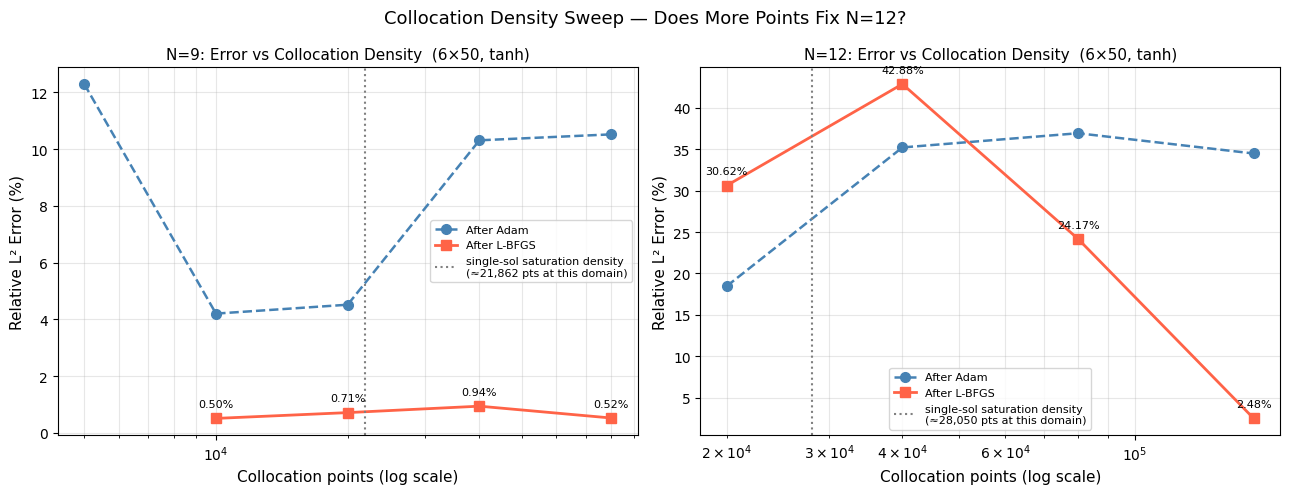

saved: collocation_sweep.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, N in zip(axes, [9, 12]):
    runs = {k: v for k, v in sweep_results.items() if v['N'] == N}
    counts  = [v['n_pde']        for v in runs.values()]
    l2_adam = [v['l2_adam']*100  for v in runs.values()]
    l2_fin  = [v['l2_final']*100 for v in runs.values()]

    # sort by n_pde
    order = np.argsort(counts)
    counts  = [counts[i]  for i in order]
    l2_adam = [l2_adam[i] for i in order]
    l2_fin  = [l2_fin[i]  for i in order]

    ax.semilogx(counts, l2_adam, 'o--', color='steelblue', linewidth=1.8,
                markersize=7, label='After Adam')
    ax.semilogx(counts, l2_fin,  's-',  color='tomato',    linewidth=2.0,
                markersize=7, label='After L-BFGS')

    # annotate final values
    for c, e in zip(counts, l2_fin):
        ax.annotate(f'{e:.2f}%', (c, e), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

    # mark the ~33/unit² reference density from single-soliton paper
    xl, xr = configs_meta[N][2]
    area = (xr - xl) * T_END
    ref_pts = int(33 * area)   # same density as single-soliton saturation
    ax.axvline(ref_pts, color='gray', linestyle=':', linewidth=1.5,
               label=f'single-sol saturation density\n(≈{ref_pts:,} pts at this domain)')

    ax.set_xlabel('Collocation points (log scale)', fontsize=11)
    ax.set_ylabel('Relative L² Error (%)', fontsize=11)
    ax.set_title(f'N={N}: Error vs Collocation Density  (6×50, tanh)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Collocation Density Sweep — Does More Points Fix N=12?', fontsize=13)
plt.tight_layout()
plt.savefig('collocation_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: collocation_sweep.png')

In [16]:
print('\n--- INTERPRETATION ---')
for N in [9, 12]:
    runs = {k: v for k, v in sweep_results.items() if v['N'] == N}
    counts = sorted([v['n_pde'] for v in runs.values()])
    errors = [next(v['l2_final']*100 for v in runs.values() if v['n_pde']==c) for c in counts]

    print(f'\nN={N}:')
    for c, e in zip(counts, errors):
        print(f'  n_pde={c:>7,}  ->  L2={e:.4f}%')

    # check if it saturates (last two values within 10% of each other)
    if len(errors) >= 2:
        rel_change = abs(errors[-1] - errors[-2]) / (errors[-2] + 1e-10)
        if rel_change < 0.10:
            print(f'  => SATURATED (last two runs differ by {rel_change*100:.1f}%) — optimization bottleneck, adding points wont help')
        else:
            print(f'  => still improving ({rel_change*100:.1f}% change at top end) — more points may help')


--- INTERPRETATION ---

N=9:
  n_pde=  5,000  ->  L2=nan%
  n_pde= 10,000  ->  L2=0.5043%
  n_pde= 20,000  ->  L2=0.7087%
  n_pde= 40,000  ->  L2=0.9358%
  n_pde= 80,000  ->  L2=0.5185%
  => still improving (44.6% change at top end) — more points may help

N=12:
  n_pde= 20,000  ->  L2=30.6183%
  n_pde= 40,000  ->  L2=42.8802%
  n_pde= 80,000  ->  L2=24.1723%
  n_pde=160,000  ->  L2=2.4788%
  => still improving (89.7% change at top end) — more points may help
